
# FireRisk AI — Etapa 1: entendimento, preparação e EDA

## Objetivo

O objetivo desta etapa é preparar uma base de dados consolidada para um problema de classificação:

> **Prever se haverá pelo menos um foco de queimada em determinado município e dia.**

A variável alvo criada é `fire_occurrence`:

- `0`: não houve foco de queimada no município naquele dia;
- `1`: houve pelo menos um foco de queimada no município naquele dia.

A unidade de análise adotada é **município-dia**.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from pathlib import Path

pd.set_option('display.max_columns', 100)



## 1. Fontes de dados

Foram utilizados quatro arquivos:

- `BDMEP-2025.csv`: dados meteorológicos;
- `BDMEP-estacao.csv`: cadastro das estações meteorológicas;
- `MapBiomas.csv`: área por classe de cobertura do solo;
- `queimadas_2024_2025.zip`: focos de queimadas.

A base de queimadas de 2025 vai até **12/02/2025**, enquanto a meteorologia segue até junho. Por isso, para evitar períodos incompatíveis, foi utilizada a janela comum entre **01/01/2025 e 12/02/2025**.



## 2. Preparação e consolidação

A consolidação completa está implementada em `src/consolidar_base.py`.

Principais etapas aplicadas:

1. leitura dos dados meteorológicos em blocos (`chunksize`) por causa do tamanho do arquivo;
2. filtro do período comum;
3. identificação e remoção de duplicidades;
4. consolidação de possíveis registros repetidos no mesmo `id_estacao + data + hora`;
5. agregação dos dados meteorológicos para estação-dia;
6. associação das estações aos municípios;
7. agregação final para município-dia;
8. agregação dos focos de queimadas por município-dia;
9. criação de `fire_occurrence`;
10. incorporação dos dados de MapBiomas de 2021;
11. criação de variáveis de calendário.

### Observação importante sobre duplicidades

Na janela estudada, o arquivo meteorológico tinha aproximadamente o dobro do número esperado de registros horários. Depois da remoção de duplicatas exatas e consolidação por estação/data/hora, cada estação-dia ficou com 24 posições horárias.


In [2]:

# Para reconstruir a base a partir dos arquivos brutos, use:
#
# from pathlib import Path
# import sys
# sys.path.append('../src')
# from consolidar_base import consolidar_base
#
# RAW_DIR = Path('/mnt/data')  # ajuste conforme o ambiente
# consolidar_base(RAW_DIR, Path('../data/processed/dataset_ml.csv'))
#
# Nesta cópia do projeto, a base consolidada já foi gerada.

DATA_PATH = Path('../data/processed/dataset_ml.csv')
df = pd.read_csv(DATA_PATH, parse_dates=['data'])

print('Dimensão da base:', df.shape)
print('Período:', df['data'].min().date(), 'até', df['data'].max().date())
print('Municípios:', df['id_municipio'].nunique())
df.head()


Dimensão da base: (23306, 51)
Período: 2025-01-01 até 2025-02-12
Municípios: 542


,data,id_municipio,id_municipio_nome,sigla_uf,sigla_uf_nome,latitude,longitude,altitude,n_estacoes,mes,dia_do_ano,dia_semana,precipitacao_diaria,pressao_media,radiacao_global_diaria,temperatura_media,temperatura_maxima,temperatura_minima,umidade_media,rajada_maxima,vento_medio,mb_area_class_0,mb_area_class_3,mb_area_class_4,mb_area_class_5,mb_area_class_9,mb_area_class_11,mb_area_class_12,mb_area_class_13,mb_area_class_15,mb_area_class_20,mb_area_class_21,mb_area_class_23,mb_area_class_24,mb_area_class_25,mb_area_class_29,mb_area_class_30,mb_area_class_31,mb_area_class_32,mb_area_class_33,mb_area_class_39,mb_area_class_40,mb_area_class_41,mb_area_class_46,mb_area_class_47,mb_area_class_48,mb_area_class_49,mb_area_class_50,mb_area_class_62,focos_queimada,fire_occurrence
0,2025-01-01,1100023,Ariquemes,RO,Rondônia,-9.948889,-62.961944,128.44,1,1,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1403.03625,26.358091,0.0,0.0,2.835432,28.097429,0.0,2763.771446,0.0,0.0,0.0,34.213608,0.0,0.0,34.864526,0.0,0.0,59.27356,63.654757,0.0,9.97975,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,2025-01-02,1100023,Ariquemes,RO,Rondônia,-9.948889,-62.961944,128.44,1,1,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1403.03625,26.358091,0.0,0.0,2.835432,28.097429,0.0,2763.771446,0.0,0.0,0.0,34.213608,0.0,0.0,34.864526,0.0,0.0,59.27356,63.654757,0.0,9.97975,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,2025-01-03,1100023,Ariquemes,RO,Rondônia,-9.948889,-62.961944,128.44,1,1,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1403.03625,26.358091,0.0,0.0,2.835432,28.097429,0.0,2763.771446,0.0,0.0,0.0,34.213608,0.0,0.0,34.864526,0.0,0.0,59.27356,63.654757,0.0,9.97975,0.0,0.0,0.0,0.0,0.0,0.0,0,0
3,2025-01-04,1100023,Ariquemes,RO,Rondônia,-9.948889,-62.961944,128.44,1,1,4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1403.03625,26.358091,0.0,0.0,2.835432,28.097429,0.0,2763.771446,0.0,0.0,0.0,34.213608,0.0,0.0,34.864526,0.0,0.0,59.27356,63.654757,0.0,9.97975,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,2025-01-05,1100023,Ariquemes,RO,Rondônia,-9.948889,-62.961944,128.44,1,1,5,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1403.03625,26.358091,0.0,0.0,2.835432,28.097429,0.0,2763.771446,0.0,0.0,0.0,34.213608,0.0,0.0,34.864526,0.0,0.0,59.27356,63.654757,0.0,9.97975,0.0,0.0,0.0,0.0,0.0,0.0,0,0



## 3. Tamanho e estrutura da base

A base final possui **23.306 observações**, referentes a **542 municípios** durante 43 dias.

Ela combina:

- variáveis meteorológicas;
- localização geográfica;
- variáveis de calendário;
- áreas das classes do MapBiomas;
- quantidade de focos;
- variável alvo binária.


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23306 entries, 0 to 23305
Data columns (total 51 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   data                    23306 non-null  datetime64[ns]
 1   id_municipio            23306 non-null  int64         
 2   id_municipio_nome       23306 non-null  object        
 3   sigla_uf                23306 non-null  object        
 4   sigla_uf_nome           23306 non-null  object        
 5   latitude                23306 non-null  float64       
 6   longitude               23306 non-null  float64       
 7   altitude                23306 non-null  float64       
 8   n_estacoes              23306 non-null  int64         
 9   mes                     23306 non-null  int64         
 10  dia_do_ano              23306 non-null  int64         
 11  dia_semana              23306 non-null  int64         
 12  precipitacao_diaria     15862 non-null  float6


## 4. Distribuição da variável alvo


,quantidade,percentual
fire_occurrence,,
0,19700,84.53
1,3606,15.47


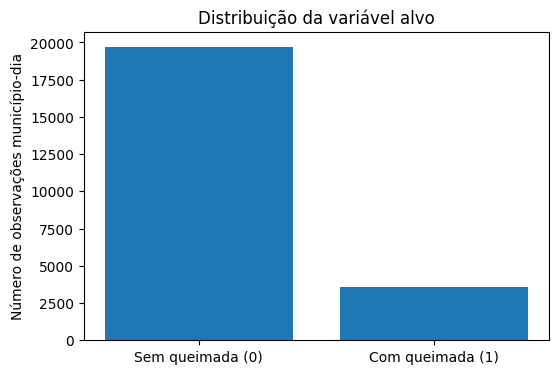

In [4]:

target_counts = df['fire_occurrence'].value_counts().sort_index()
target_pct = df['fire_occurrence'].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    'quantidade': target_counts,
    'percentual': target_pct.round(2)
}))

plt.figure(figsize=(6,4))
plt.bar(['Sem queimada (0)', 'Com queimada (1)'], target_counts.values)
plt.ylabel('Número de observações município-dia')
plt.title('Distribuição da variável alvo')
plt.show()



A classe positiva representa aproximadamente **15,47%** das observações.

Existe desbalanceamento, mas ele não é extremo. Na modelagem, a acurácia não deve ser usada sozinha. O projeto deve acompanhar principalmente **Recall, Precision, F1-score e ROC-AUC**.



## 5. Dados ausentes


In [5]:

missing = (
    df.isna().mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename('percentual_ausente')
      .to_frame()
)

display(missing[missing['percentual_ausente'] > 0].head(15).round(2))


,percentual_ausente
precipitacao_diaria,31.94
rajada_maxima,25.74
vento_medio,25.62
umidade_media,23.63
radiacao_global_diaria,21.72
temperatura_minima,20.29
temperatura_maxima,20.29
temperatura_media,20.21
pressao_media,19.44



Os maiores percentuais de dados ausentes aparecem em variáveis meteorológicas, principalmente precipitação, vento, umidade e radiação.

Nesta etapa, os valores ausentes foram **mantidos** na base consolidada. Isso foi feito para evitar uma imputação antes da divisão treino/teste.

Na Etapa 2, a imputação deve ser ajustada somente com os dados de treinamento, preferencialmente dentro de uma `Pipeline` do scikit-learn.



## 6. Estatísticas descritivas


In [6]:

weather_cols = [
    'precipitacao_diaria',
    'pressao_media',
    'radiacao_global_diaria',
    'temperatura_media',
    'temperatura_maxima',
    'temperatura_minima',
    'umidade_media',
    'rajada_maxima',
    'vento_medio',
    'altitude'
]

display(df[weather_cols + ['focos_queimada', 'fire_occurrence']].describe().T)


,count,mean,std,min,25%,50%,75%,max
precipitacao_diaria,15862.0,5.760839,12.538625,0.000000,0.000000,0.200000,5.400000,171.800000
pressao_media,18775.0,962.686447,36.557578,822.991667,936.418750,965.825000,993.416667,1017.937500
radiacao_global_diaria,18244.0,19537.039209,7025.685450,0.000000,14936.650000,20156.150000,24782.550000,87895.400000
temperatura_media,18595.0,25.226385,2.630800,13.137500,23.687500,25.391667,26.866667,36.208333
temperatura_maxima,18577.0,31.178394,3.158863,15.000000,29.200000,31.400000,33.300000,43.800000
temperatura_minima,18577.0,21.205360,2.724614,7.300000,19.600000,21.500000,23.000000,33.300000
umidade_media,17799.0,75.901381,11.092176,7.000000,69.333333,77.285714,83.791667,100.000000
rajada_maxima,17306.0,9.118441,2.895278,0.000000,7.200000,8.800000,10.600000,35.600000
vento_medio,17335.0,1.772516,1.014418,0.000000,1.108893,1.595833,2.267424,10.204167
altitude,23306.0,416.939740,331.949619,2.000000,134.000000,369.110000,645.000000,1790.380000



## 7. Outliers

Foi utilizado o método do intervalo interquartil (IQR) para identificar valores extremos.

Os outliers não foram removidos automaticamente porque condições meteorológicas extremas podem ser reais e importantes para o fenômeno de queimadas. O objetivo aqui é identificar e documentar esses pontos.


In [7]:

outlier_rows = []

for col in weather_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()

    outlier_rows.append({
        'variavel': col,
        'q1': q1,
        'q3': q3,
        'limite_inferior': lower,
        'limite_superior': upper,
        'n_outliers': n_outliers,
        'pct_outliers': 100 * n_outliers / len(s)
    })

outliers = pd.DataFrame(outlier_rows).sort_values('pct_outliers', ascending=False)
display(outliers.round(2))


,variavel,q1,q3,limite_inferior,limite_superior,n_outliers,pct_outliers
0,precipitacao_diaria,0.00,5.40,-8.10,13.50,2258,14.24
8,vento_medio,1.11,2.27,-0.63,4.01,525,3.03
7,rajada_maxima,7.20,10.60,2.10,15.70,523,3.02
5,temperatura_minima,19.60,23.00,14.50,28.10,498,2.68
3,temperatura_media,23.69,26.87,18.92,31.64,485,2.61
6,umidade_media,69.33,83.79,47.65,105.48,291,1.63
4,temperatura_maxima,29.20,33.30,23.05,39.45,263,1.42
9,altitude,134.00,645.00,-632.50,1411.50,172,0.74
1,pressao_media,936.42,993.42,850.92,1078.91,129,0.69
2,radiacao_global_diaria,14936.65,24782.55,167.80,39551.40,112,0.61



A precipitação apresenta o maior percentual de observações classificadas como outliers pelo IQR. Isso é esperado porque muitos dias têm pouca ou nenhuma chuva e alguns dias apresentam volumes bem maiores.

Como esses extremos podem carregar informação relevante sobre risco de fogo, eles foram preservados.



## 8. Correlação entre as variáveis


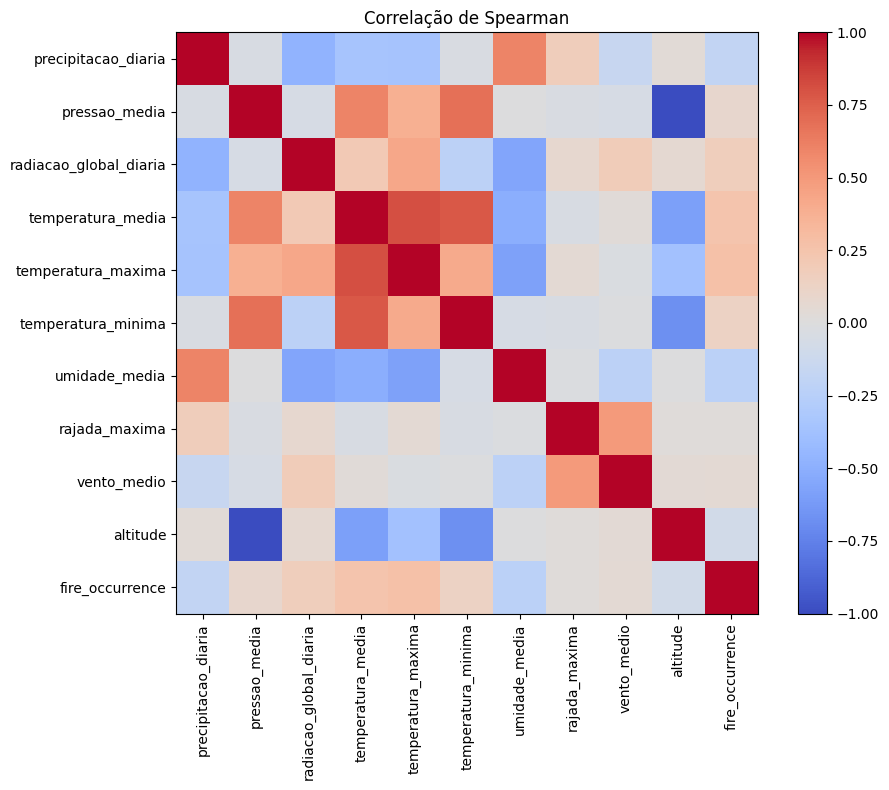

,correlacao_com_alvo
temperatura_maxima,0.268
temperatura_media,0.249
umidade_media,-0.230
precipitacao_diaria,-0.181
radiacao_global_diaria,0.167
temperatura_minima,0.125
pressao_media,0.083
altitude,-0.078
vento_medio,0.052
rajada_maxima,0.016


In [8]:

corr_cols = weather_cols + ['fire_occurrence']
corr = df[corr_cols].corr(method='spearman')

plt.figure(figsize=(10,8))
im = plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar(im)
plt.title('Correlação de Spearman')
plt.tight_layout()
plt.show()

target_corr = corr['fire_occurrence'].drop('fire_occurrence')
display(
    target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
    .rename('correlacao_com_alvo')
    .to_frame()
    .round(3)
)



As maiores associações observadas com a ocorrência de queimadas foram:

- temperatura máxima: relação positiva;
- temperatura média: relação positiva;
- umidade média: relação negativa;
- precipitação diária: relação negativa;
- radiação global diária: relação positiva.

Essas correlações são úteis para orientar a análise, mas não demonstram causalidade.



## 9. Comparação visual — umidade e temperatura


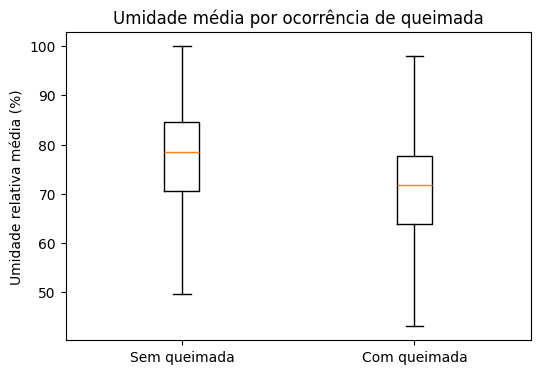

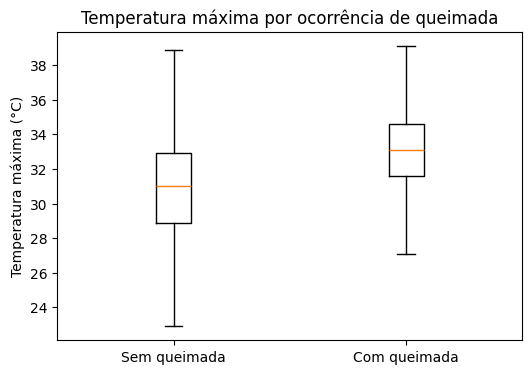

In [9]:

sem_fogo = df.loc[df['fire_occurrence'] == 0, 'umidade_media'].dropna()
com_fogo = df.loc[df['fire_occurrence'] == 1, 'umidade_media'].dropna()

plt.figure(figsize=(6,4))
plt.boxplot([sem_fogo, com_fogo],
            tick_labels=['Sem queimada', 'Com queimada'],
            showfliers=False)
plt.ylabel('Umidade relativa média (%)')
plt.title('Umidade média por ocorrência de queimada')
plt.show()

sem_fogo_temp = df.loc[df['fire_occurrence'] == 0, 'temperatura_maxima'].dropna()
com_fogo_temp = df.loc[df['fire_occurrence'] == 1, 'temperatura_maxima'].dropna()

plt.figure(figsize=(6,4))
plt.boxplot([sem_fogo_temp, com_fogo_temp],
            tick_labels=['Sem queimada', 'Com queimada'],
            showfliers=False)
plt.ylabel('Temperatura máxima (°C)')
plt.title('Temperatura máxima por ocorrência de queimada')
plt.show()



## 10. Teste de hipótese estatístico

### Premissa de negócio

Dias com ocorrência de queimadas apresentam menor umidade relativa do ar.

### Hipóteses

- **H0:** a distribuição de umidade média nos dias com queimadas não é menor do que nos dias sem queimadas.
- **H1:** a umidade média nos dias com queimadas é menor do que nos dias sem queimadas.

Foi utilizado o teste **Mann–Whitney U unilateral**, pois ele não exige normalidade das distribuições.


In [10]:

humidity_fire = df.loc[df['fire_occurrence'] == 1, 'umidade_media'].dropna()
humidity_no_fire = df.loc[df['fire_occurrence'] == 0, 'umidade_media'].dropna()

u_stat, p_value = mannwhitneyu(
    humidity_fire,
    humidity_no_fire,
    alternative='less'
)

print('Média - com queimada:', round(humidity_fire.mean(), 2))
print('Média - sem queimada:', round(humidity_no_fire.mean(), 2))
print('Mediana - com queimada:', round(humidity_fire.median(), 2))
print('Mediana - sem queimada:', round(humidity_no_fire.median(), 2))
print('Estatística U:', u_stat)
print('p-valor:', p_value)

alpha = 0.05
if p_value < alpha:
    print('Resultado: rejeitamos H0.')
else:
    print('Resultado: não rejeitamos H0.')


Média - com queimada: 70.08
Média - sem queimada: 76.96
Mediana - com queimada: 71.67
Mediana - sem queimada: 78.42
Estatística U: 13041652.0
p-valor: 2.0558985762019714e-206
Resultado: rejeitamos H0.



### Interpretação do teste

Na amostra analisada:

- a umidade média nos dias com queimada ficou em aproximadamente **70,08%**;
- nos dias sem queimada, ficou em aproximadamente **76,96%**;
- o p-valor foi muito menor que 0,05.

Assim, rejeitamos H0. Os dados mostram evidência estatística de que os dias com ocorrência de queimadas apresentam umidade menor.

Esse resultado faz sentido para a hipótese de negócio e mostra que a umidade deve ser considerada uma variável importante na modelagem.



## 11. KPIs definidos para a modelagem

Na Etapa 2, os modelos serão comparados usando:

- **Recall**;
- **Precision**;
- **F1-score**;
- **ROC-AUC**;
- **Acurácia**;
- **Matriz de confusão**.

O **Recall da classe positiva** será tratado como KPI principal porque um falso negativo representa um município-dia em que ocorreu uma queimada, mas o modelo não emitiu o alerta.



## 12. Conclusão da Etapa 1

Nesta etapa, as quatro fontes de dados foram consolidadas em uma base única no nível município-dia.

A base final possui **23.306 observações**, cobrindo **542 municípios** entre 01/01/2025 e 12/02/2025. Aproximadamente **15,5%** das observações tiveram pelo menos um foco de queimada.

Durante a preparação dos dados, foi identificada uma duplicidade importante na base meteorológica. Depois da limpeza, os registros foram agregados para o nível diário e integrados às informações de queimadas e MapBiomas.

A análise exploratória mostrou que temperaturas mais altas apresentam associação positiva com a ocorrência de queimadas, enquanto umidade e precipitação apresentam associação negativa.

O teste de hipótese também mostrou uma diferença estatisticamente significativa na umidade entre dias com e sem queimadas.

Os dados apresentam valores ausentes, principalmente em algumas variáveis meteorológicas. Eles foram mantidos nesta etapa para que o tratamento seja realizado corretamente dentro da pipeline de modelagem, evitando vazamento de informação.

Com isso, considero que a base está consolidada e documentada para iniciar a Etapa 2, na qual serão treinados e comparados diferentes modelos de classificação.


In [11]:

# Salva novamente a base consolidada ao final do notebook.
# Nenhuma variável alvo é usada para preencher features nesta etapa.

OUTPUT_PATH = Path('../data/processed/dataset_ml.csv')
df.to_csv(OUTPUT_PATH, index=False)

print('Base final salva em:', OUTPUT_PATH)
print('Dimensão final:', df.shape)


Base final salva em: ../data/processed/dataset_ml.csv
Dimensão final: (23306, 51)
